# Genie Code — Prompt Playbook for Governed Assets (optional track)

**Pre-Hackathon Enablement · Optional / parallel track** (not numbered — needs only Notebooks 1–2)

The deck's last topic: *"Genie Code writing and checking pipeline — SQL and App
code under Unity Catalog governance. **A person reviews and approves that code
before it ships.**"*

**Genie Code** is Databricks' catalog-aware, agentic coding assistant. You work
with it **interactively** — in the SQL editor, a notebook, or the assistant panel
— describing what you want in plain English. Grounded in your Unity Catalog
metadata, it proposes SQL / code and can **create or modify governed assets**
(views, metric views, functions, tables), with permissions, lineage, and audit
all enforced by Unity Catalog.

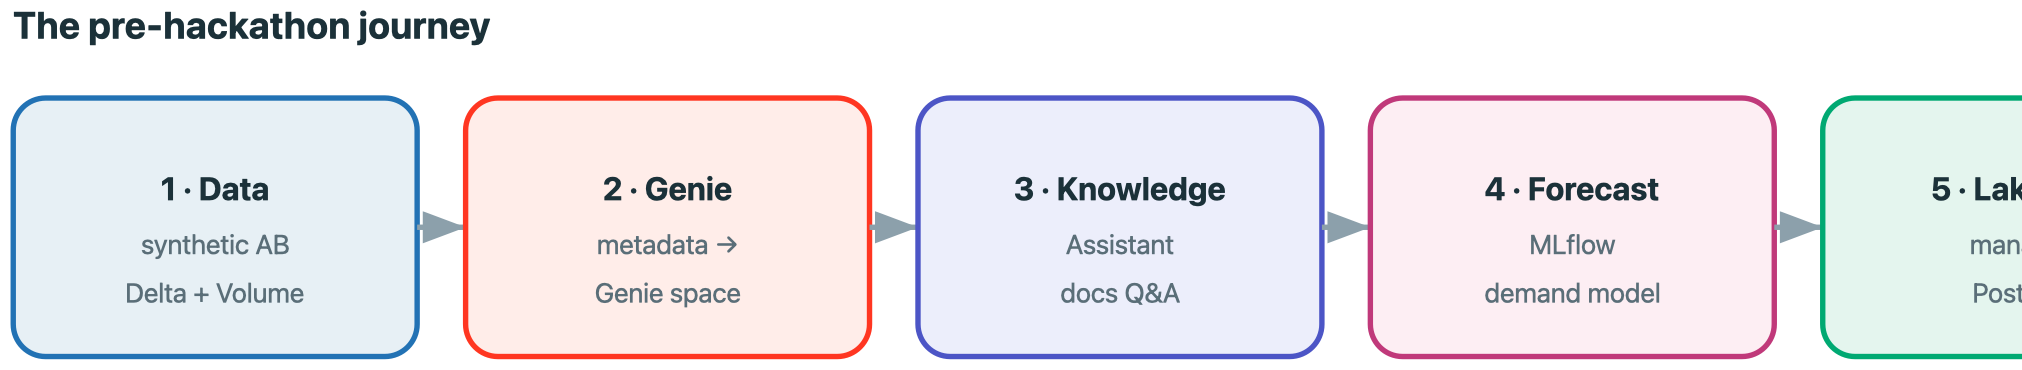

Because it's interactive, you don't call it from *this* notebook. Instead, this
notebook is a **playbook**: ready-to-paste prompts (grounded in your beverage
supply-chain schema) for common tasks, plus the review-and-ship discipline.

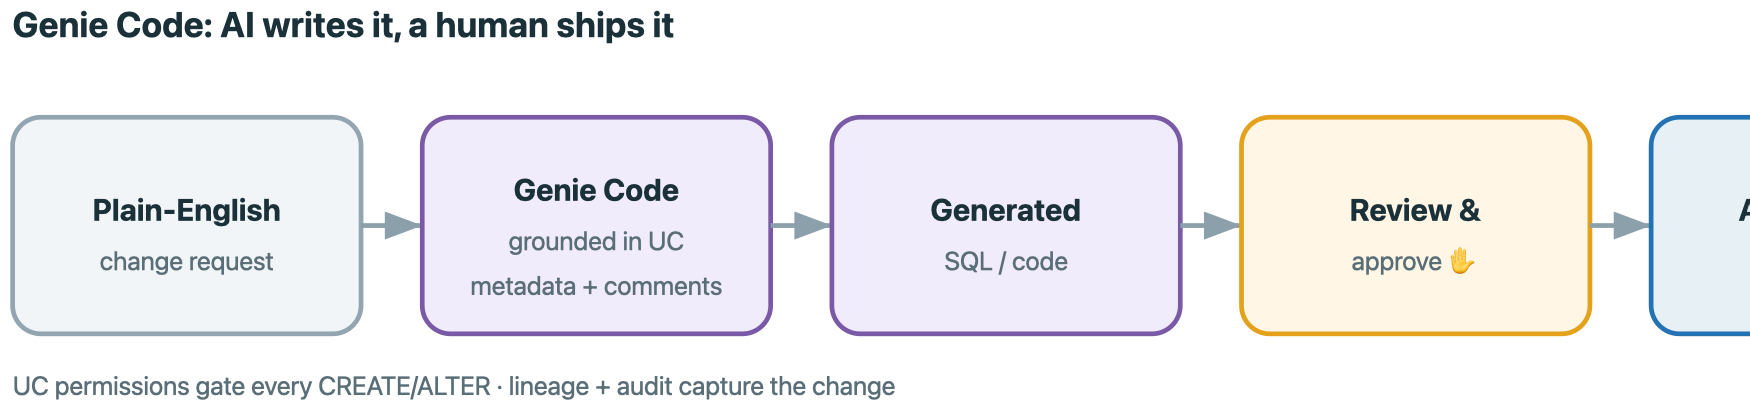

### The golden rule
Genie Code writes the code; **a human reviews and approves before it ships.**
Treat every proposed `CREATE` / `ALTER` / `DROP` like a pull request — read it,
run it against dev, confirm the result, *then* apply.

### What you'll do
1. Open Genie Code and point it at **your** catalog/schema
2. Generate **personalized prompts** for your schema (a cell below)
3. Paste them into Genie Code to **create / change** governed assets
4. **Review → approve** what it proposes, then **verify** the asset here
5. Understand the **governance** around it

> **Prerequisites:** Notebooks 1–2 completed (the 4 curated tables + comments — the
> metadata Genie Code reads). Access to Genie Code / Databricks Assistant in your
> workspace.

## Step 1 · Where to find Genie Code, and how to give it context

- Open it from the **SQL editor** or a **notebook** — look for the Assistant /
  Genie panel (the ✨ / assistant icon), or the assistant cell in a notebook.
- **Give it context:** select your catalog and schema (or `USE` your schema) so
  it grounds on the right tables. The richer your **table & column comments**
  (Notebook 2, Step 2), the better its output — that metadata is what it reads.
- Keep each ask **specific**: name the target object, the tables to use, the
  measures/filters, and the exact column names.

## Step 2 · Generate personalized prompts

Set your catalog/schema, run the cell, and copy any prompt straight into Genie
Code. Each one already references your fully-qualified table names.

In [ ]:
# Create the widgets. Run this cell, set the values up top, then run the next cell.
dbutils.widgets.text("catalog", "technology_dev", "Unity Catalog catalog")
dbutils.widgets.text("schema", "abi_hackathon", "Schema base (username appended — matches NB1)")

In [ ]:
# Now read the widgets and build the personalized prompts for your schema.
import re
CATALOG = dbutils.widgets.get("catalog").strip()
_user = spark.sql("SELECT current_user()").collect()[0][0]
SCHEMA = f"{dbutils.widgets.get('schema').strip()}_{re.sub(r'[^a-z0-9]+', '_', _user.split('@')[0].lower()).strip('_')}"
FQ = f"{CATALOG}.{SCHEMA}"

PROMPTS = {
    "Create a curated view":
        f"Using the tables in {FQ} (orders, products, distributors, shipments), "
        f"create a view {FQ}.vw_segment_monthly_sales that shows, for Delivered "
        f"orders only, monthly revenue (SUM of order_value_usd) and total cases "
        f"(SUM of quantity_cases) by product commercial segment (products.category). "
        f"Join orders to products on product_sku. Show me the SQL before creating it.",

    "Modify an existing view":
        f"Update the view {FQ}.vw_segment_monthly_sales to also include "
        f"avg_price_per_case (revenue divided by total cases, rounded to 2 decimals), "
        f"keeping all existing columns.",

    "Create a metric view (semantic layer)":
        f"Create a metric view over {FQ}.orders joined to {FQ}.products and "
        f"{FQ}.distributors, with measures total_revenue (SUM order_value_usd) and "
        f"total_cases (SUM quantity_cases), and dimensions segment (products.category), "
        f"brand, region (distributors.region), and order month. Delivered orders only.",

    "Create a SQL function (UDF)":
        f"Create a SQL function {FQ}.is_late(requested DATE, actual DATE) that returns "
        f"TRUE when actual > requested (a late delivery). Add a comment describing it.",

    "Build an aggregate table for a dashboard":
        f"Create a table {FQ}.freight_by_carrier_monthly that aggregates, per carrier "
        f"per month, total freight_cost_usd, total shipments, and on-time rate "
        f"(percent of shipments where on_time is true) from {FQ}.shipments. Delivered only.",

    "Add governed documentation":
        f"Review {FQ}.shipments and propose COMMENT statements for any columns whose "
        f"meaning isn't obvious, then apply them. Keep comments concise and business-first.",

    "Explain / optimize an existing query":
        f"Explain what this query does and suggest a more efficient version if possible:\n"
        f"SELECT d.region, SUM(o.order_value_usd) FROM {FQ}.orders o "
        f"JOIN {FQ}.distributors d ON o.distributor_id=d.distributor_id GROUP BY d.region",
}

print("Copy any prompt below into Genie Code:\n")
for i, (title, prompt) in enumerate(PROMPTS.items(), 1):
    print(f"{'='*78}\n{i}. {title}\n{'-'*78}\n{prompt}\n")

## Step 3 · Review before you ship ✋

Genie Code proposes; **you decide**. For anything that creates or changes an
asset, before you click apply:
- **Read the SQL.** Do the joins, filters, and column names match what you meant?
  (Genie Code can occasionally use a plausible-but-wrong column — the comments in
  Notebook 2 make this rare, but *check*.)
- **Dry-run it.** Run a `SELECT`/`EXPLAIN` of the logic first, or apply it to a dev
  schema, and eyeball the result.
- **Then apply**, and treat the generated SQL like code: keep it in source control
  / a Databricks Asset Bundle, not just an ephemeral chat.

## Step 4 · Verify what Genie Code created

After you run a prompt in Genie Code and approve the asset, come back and confirm
it here. This cell lists the views, functions, and tables now in your schema so
you can see what landed.

In [ ]:
print("Views:")
display(spark.sql(f"SHOW VIEWS IN {FQ}"))
print("Tables:")
display(spark.sql(f"SHOW TABLES IN {FQ}"))
print("Functions:")
display(spark.sql(f"SHOW USER FUNCTIONS IN {FQ}"))

In [ ]:
# If you created vw_segment_monthly_sales (prompt 1/2), preview it. Otherwise
# swap in whatever asset Genie Code built for you.
try:
    display(spark.sql(f"SELECT * FROM {FQ}.vw_segment_monthly_sales ORDER BY 1 LIMIT 12"))
except Exception as e:
    print(f"(Create it in Genie Code first, or change the name.) {e}")

## Step 5 · The governance around it

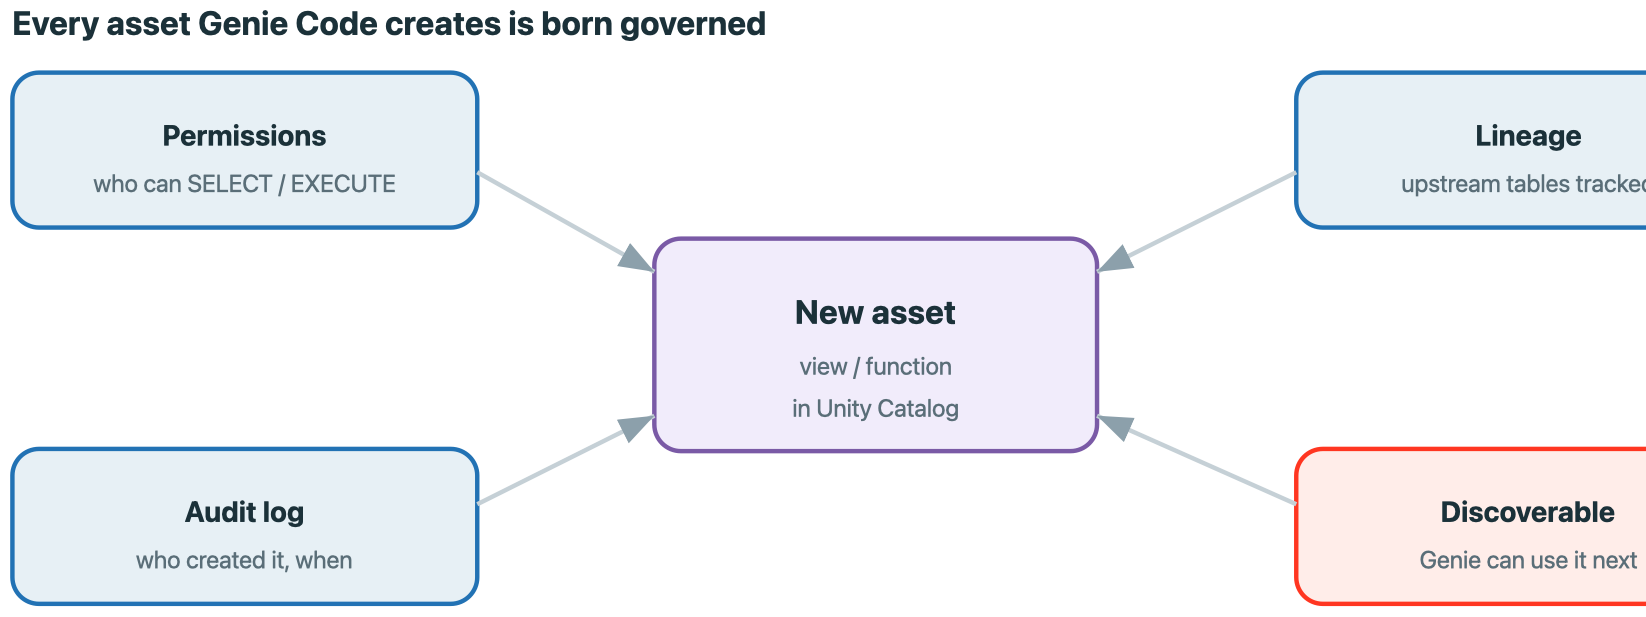

Genie Code operates **inside** Unity Catalog — it never bypasses it:
- **Permissions gate everything.** A `CREATE`/`ALTER` only succeeds if *your*
  identity has `CREATE`/`MODIFY` on the target schema. Point it at **dev** first;
  give automation identities least privilege.
- **Lineage & audit.** Every applied statement shows up in UC lineage and audit
  logs — you can always answer *"where did this asset come from?"*
- **Human approval is the control.** What Genie Code proposes is a suggestion
  until a person approves it. Disable any auto-run for production assets.
- **Source-control the output.** Commit approved SQL/code and ship via CI/CD or
  Asset Bundles.

Check provenance for something you just created (swap in your asset name):

In [ ]:
try:
    display(spark.sql(f"DESCRIBE EXTENDED {FQ}.vw_segment_monthly_sales"))
except Exception as e:
    print(f"(Create the asset in Genie Code first.) {e}")

## ✅ Recap

**Genie Code** accelerates building governed assets — SQL, views, metric views,
functions, app code — by turning plain-English asks into code, grounded in your
Unity Catalog metadata. Your job: **prompt it well, review what it proposes, and
approve before it ships.** Keep this playbook of prompts handy during the
hackathon and adapt them to your own tables.

That's the **governed AI-assisted development** pattern — a separate, optional track
off Notebooks 1–2. The numbered series (Data → Genie → Knowledge Assistant →
Forecast → Lakebase) comes together in **Notebook 6 · the Databricks App**.